In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold

In [28]:
df = pd.read_parquet("../Data/Parquet/Enhanced.parquet", engine='pyarrow')

In [6]:
print(df.columns)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Distance',
       'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi',
       'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'PHOTIC_ZONE',
       'baseline_depth', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED',
       'K_PAR'],
      dtype='object')


In [56]:

print((df['Lat_Dec'] == -99.0).sum())
print((df['Lon_Dec'] == -99.0).sum())
print(len(df['Lat_Dec']))
print(df.head())
print(df['Lon_Dec'].value_counts())

0
0
2388
   ORD_OCC    CAST_ID         DATE_TIME_UTC         DATE_TIME_PST  LAT_DEC  \
0      1.0  9308_001d  1993-08-11T12:06:54Z  1993-08-11T04:06:54Z    -99.0   
1      6.0  9308_006d  1993-08-12T10:57:23Z  1993-08-12T02:57:23Z    -99.0   
2     10.0  9308_010d  1993-08-13T10:08:57Z  1993-08-13T02:08:57Z    -99.0   
3     11.0  9308_011d  1993-08-13T14:53:13Z  1993-08-13T06:53:13Z    -99.0   
4     14.0  9308_014d  1993-08-14T10:19:40Z  1993-08-14T02:19:40Z    -99.0   

   LON_DEC       STA_ID  LINE    STA  DEPTH  ...  IntChl  IntC14  TimeZone  \
0    -99.0  093.3 026.7  93.3   26.7   28.0  ...    30.8   489.3       8.0   
1    -99.0  093.3 045.0  93.3   45.0   46.0  ...    21.4    70.0       8.0   
2    -99.0  093.3 070.0  93.3   70.0   57.0  ...    24.4   207.1       8.0   
3    -99.0  093.3 080.0  93.3   80.0   58.0  ...    23.5     NaN       NaN   
4    -99.0  093.3 110.0  93.3  110.0   77.0  ...    23.7   106.2       8.0   

   Visibility  PHOTIC_ZONE  baseline_depth  XMISS_SUM

In [57]:
# ── Diagnose Lon_Dec values ──────────────────────────────────────────────────
print("Lon_Dec summary statistics:")
print(df['Lon_Dec'].describe())

print(f"\nTotal rows: {len(df)}")
print(f"NaN:              {df['Lon_Dec'].isna().sum():>8}  ({100*df['Lon_Dec'].isna().mean():.1f}%)")
print(f"== -99:           {(df['Lon_Dec'] == -99).sum():>8}  ({100*(df['Lon_Dec'] == -99).mean():.1f}%)")
print(f"< -99 (not NaN):  {((df['Lon_Dec'] < -99) & df['Lon_Dec'].notna()).sum():>8}  ({100*((df['Lon_Dec'] < -99) & df['Lon_Dec'].notna()).mean():.1f}%)")
print(f"<= -99 total:     {(df['Lon_Dec'] <= -99).sum():>8}  ({100*(df['Lon_Dec'] <= -99).mean():.1f}%)")

print("\nUnique values <= -99:")
print(sorted(df.loc[df['Lon_Dec'] <= -99, 'Lon_Dec'].unique()))

print("\nValue counts for Lon_Dec <= -99:")
print(df.loc[df['Lon_Dec'] <= -99, 'Lon_Dec'].value_counts().sort_index())

Lon_Dec summary statistics:
count    2388.000000
mean     -120.862754
std         1.964928
min      -125.773333
25%      -122.528333
50%      -120.915620
75%      -119.318333
max      -117.296666
Name: Lon_Dec, dtype: float64

Total rows: 2388
NaN:                     0  (0.0%)
== -99:                  0  (0.0%)
< -99 (not NaN):      2388  (100.0%)
<= -99 total:         2388  (100.0%)

Unique values <= -99:
[np.float64(-125.773333), np.float64(-125.598333), np.float64(-125.345), np.float64(-125.256666), np.float64(-125.048333), np.float64(-124.8976), np.float64(-124.89), np.float64(-124.637), np.float64(-124.635), np.float64(-124.55), np.float64(-124.48082), np.float64(-124.331666), np.float64(-124.33), np.float64(-124.328333), np.float64(-124.326666), np.float64(-124.32503), np.float64(-124.325), np.float64(-124.32412), np.float64(-124.32342), np.float64(-124.323333), np.float64(-124.3233), np.float64(-124.32303), np.float64(-124.32288), np.float64(-124.32237), np.float64(-124.32227),

#### New Dataset Features
- Transmissomter, chlorophyl, and phaeo are aggregated (summed up to photic zone depth)
- KPar

#### Rerun elastic net with new features
- Response: Secchi
- Predictors:
    - 'Lat_Dec'
    - 'Lon_Dec'
    - 'LINE'
    - 'STA'
    - 'ESTCHL_STACORR'
    - 'BAT'
    - 'DEPTH' = 'PHOTIC_ZONE'
    - 'XMISS_SUMMED'
    - 'CHL_A_SUMMED'
    - 'PHAEO_SUMMED'
    - 'K_PAR'
    - 'PAR'

The previous model used both `depth` and `pressure` which are basically trivial predictors of Secchi depth since they both are very related to Secchi depth. Rasmus also instructed to use `ESTCHL_STACORR` over `ESTCHL_CRUISECORR`. 

#### Lasso Regression — Enhanced Dataset
Filter `df` to rows where `PHOTIC_ZONE == True` and deduplicate by `CAST_COUNT` to get one row per cast. The summed/aggregated features (`XMISS_SUMMED`, `CHL_A_SUMMED`, `PHAEO_SUMMED`, `K_PAR`) are already computed in the Enhanced dataset. Replace -99 sentinel values in `LAT_DEC` / `LON_DEC` with NaN (~21% missing).

In [58]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

features = [
    'Lat_Dec', 'Lon_Dec', 'LINE', 'STA', 'ESTCHL_STACORR', 'BAT', 'DEPTH',
    'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'K_PAR', 'PAR'
]
target = 'Secchi'

# ── One row per cast: photic-zone rows already in df ────────────────────────
cast_df = (
    df[df['PHOTIC_ZONE'] == True]
    .drop_duplicates(subset='CAST_COUNT')
    .copy()
)

# Replace exactly -99 sentinel values in LAT/LON with NaN
cast_df.loc[cast_df['Lat_Dec'] == -99, 'Lat_Dec'] = np.nan
cast_df.loc[cast_df['Lon_Dec'] == -99, 'Lon_Dec'] = np.nan

cast_model = cast_df[features + [target]].copy()
print(f"Unique casts: {len(cast_model)}")

# ── Missing-value report ─────────────────────────────────────────────────────
print(f"\n{'Variable':<25} {'Missing':>8} {'% Missing':>10}")
print("-" * 45)
for col in features + [target]:
    n = cast_model[col].isna().sum()
    pct = 100 * n / len(cast_model)
    print(f"{col:<25} {n:>8} {pct:>9.1f}%")

# Drop features with >50% missing
high_missing = [f for f in features if cast_model[f].isna().mean() > 0.5]
if high_missing:
    print(f"\nDropping features with >50% missing: {high_missing}")
features_use = [f for f in features if f not in high_missing]
print(f"\nFeatures used ({len(features_use)}): {features_use}")

Unique casts: 2388

Variable                   Missing  % Missing
---------------------------------------------
Lat_Dec                          0       0.0%
Lon_Dec                          0       0.0%
LINE                             0       0.0%
STA                              0       0.0%
ESTCHL_STACORR                   9       0.4%
BAT                              0       0.0%
DEPTH                            0       0.0%
XMISS_SUMMED                     0       0.0%
CHL_A_SUMMED                     0       0.0%
PHAEO_SUMMED                     0       0.0%
K_PAR                            0       0.0%
PAR                              0       0.0%
Secchi                           0       0.0%

Features used (12): ['Lat_Dec', 'Lon_Dec', 'LINE', 'STA', 'ESTCHL_STACORR', 'BAT', 'DEPTH', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'K_PAR', 'PAR']


In [59]:
# ── Train / test split ───────────────────────────────────────────────────────
cast_complete = cast_model.dropna(subset=[target])
X = cast_complete[features_use].values
y = cast_complete[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Median imputation for remaining missing predictor values
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Standardise
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

# ── Lasso with cross-validated alpha selection ───────────────────────────────
lasso = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_sc, y_train)

y_pred_train = lasso.predict(X_train_sc)
y_pred_test  = lasso.predict(X_test_sc)

print("=" * 50)
print("LASSO REGRESSION RESULTS")
print("=" * 50)
print(f"Best alpha:  {lasso.alpha_:.6f}")
print(f"\nTrain R²:    {r2_score(y_train, y_pred_train):.4f}")
print(f"Test  R²:    {r2_score(y_test,  y_pred_test):.4f}")
print(f"Train RMSE:  {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"Test  RMSE:  {np.sqrt(mean_squared_error(y_test,  y_pred_test)):.4f}")

# 5-fold CV R² on training set
cv_scores = cross_val_score(lasso, X_train_sc, y_train, cv=5, scoring='r2')
print(f"\n5-Fold CV R²: {cv_scores}")
print(f"CV R² mean ± std: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ── Feature coefficients ─────────────────────────────────────────────────────
coef_df = pd.DataFrame({'Feature': features_use, 'Coefficient': lasso.coef_})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print(f"\n{'='*50}")
print("FEATURE COEFFICIENTS (sorted by |coef|)")
print(f"{'='*50}")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))
n_nonzero = (coef_df['Coefficient'] != 0).sum()
print(f"\nNon-zero coefficients: {n_nonzero} / {len(features_use)}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.403e+01, tolerance: 1.128e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.597e+02, tolerance: 1.128e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

LASSO REGRESSION RESULTS
Best alpha:  0.075646

Train R²:    0.6368
Test  R²:    0.6395
Train RMSE:  5.2062
Test  RMSE:  5.2009


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.633e+01, tolerance: 9.099e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.780e+02, tolerance: 9.099e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb


5-Fold CV R²: [   0.61012638    0.68896734    0.62875364 -100.97128409    0.64662249]
CV R² mean ± std: -19.6794 ± 40.6460

FEATURE COEFFICIENTS (sorted by |coef|)
       Feature  Coefficient
         DEPTH     4.042758
       Lat_Dec    -1.908931
  CHL_A_SUMMED    -1.443120
           STA     1.201167
         K_PAR     0.342669
           PAR     0.221689
ESTCHL_STACORR    -0.069830
           BAT    -0.040208
       Lon_Dec    -0.000000
          LINE     0.000000
  XMISS_SUMMED    -0.000000
  PHAEO_SUMMED    -0.000000

Non-zero coefficients: 8 / 12


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.550e+01, tolerance: 9.486e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.530e+01, tolerance: 9.486e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

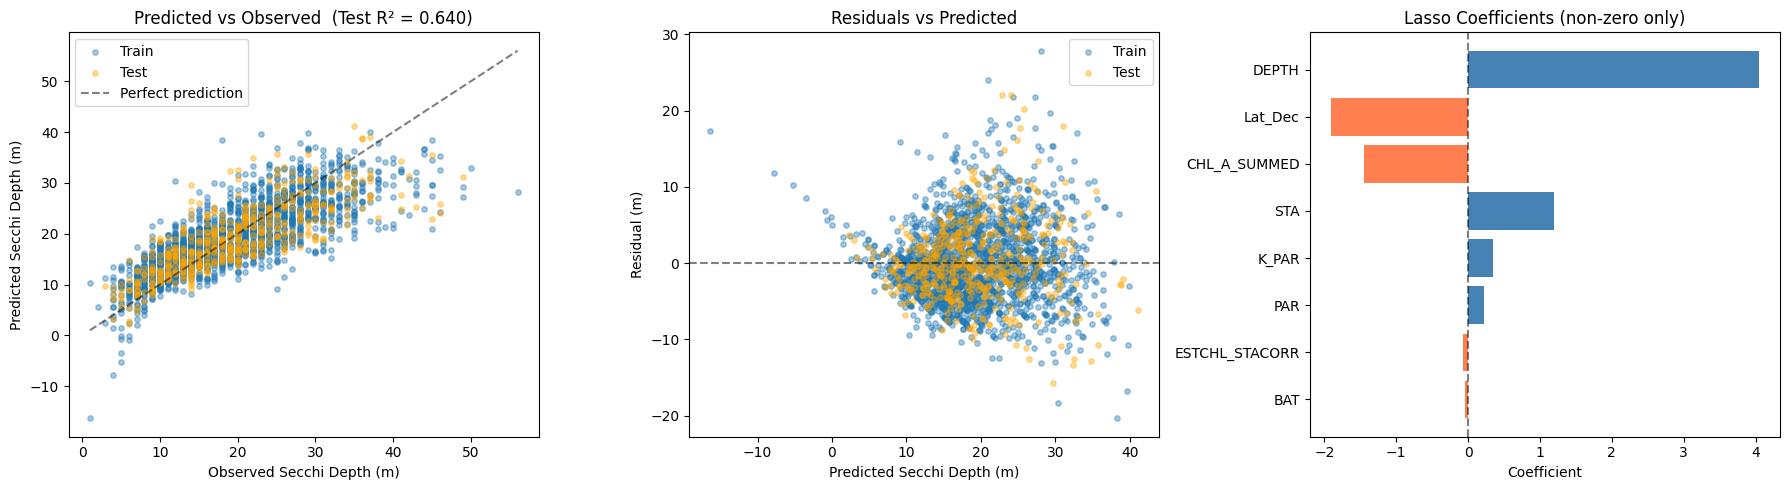

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs Observed
axes[0].scatter(y_train, y_pred_train, alpha=0.4, label='Train', s=15)
axes[0].scatter(y_test,  y_pred_test,  alpha=0.4, label='Test', color='orange', s=15)
lims = [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())]
axes[0].plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
axes[0].set_xlabel('Observed Secchi Depth (m)')
axes[0].set_ylabel('Predicted Secchi Depth (m)')
axes[0].set_title(f'Predicted vs Observed  (Test R² = {r2_score(y_test, y_pred_test):.3f})')
axes[0].legend()

# 2. Residuals vs Predicted
res_train = y_train - y_pred_train
res_test  = y_test  - y_pred_test
axes[1].scatter(y_pred_train, res_train, alpha=0.4, label='Train', s=15)
axes[1].scatter(y_pred_test,  res_test,  alpha=0.4, label='Test', color='orange', s=15)
axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Predicted Secchi Depth (m)')
axes[1].set_ylabel('Residual (m)')
axes[1].set_title('Residuals vs Predicted')
axes[1].legend()

# 3. Feature coefficient bar plot (non-zero only)
coef_nz = coef_df[coef_df['Coefficient'] != 0]
colors = ['steelblue' if c > 0 else 'coral' for c in coef_nz['Coefficient']]
axes[2].barh(range(len(coef_nz)), coef_nz['Coefficient'].values, color=colors)
axes[2].set_yticks(range(len(coef_nz)))
axes[2].set_yticklabels(coef_nz['Feature'].values)
axes[2].invert_yaxis()
axes[2].axvline(0, color='k', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Coefficient')
axes[2].set_title('Lasso Coefficients (non-zero only)')

plt.tight_layout()
plt.show()

#### Lasso Regression — Reduced Feature Set
Refit excluding `Lon_Dec`, `LINE`, `XMISS_SUMMED`, and `PHAEO_SUMMED`, whose coefficients were shrunk to zero in the model above (removed `BAT` and `ESTCHL_STACORR` also whose coefs were ~=0). Predictors: `Lat_Dec`, `STA`, `BAT`, `DEPTH`, `CHL_A_SUMMED`, `K_PAR`, `PAR`.

In [68]:
features_r2 = [
    'Lat_Dec', 'STA', 'DEPTH',
    'CHL_A_SUMMED', 'K_PAR', 'PAR'
]

cast_complete_r2 = cast_df[features_r2 + [target]].dropna(subset=[target])

X_r2 = cast_complete_r2[features_r2].values
y_r2 = cast_complete_r2[target].values

X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(
    X_r2, y_r2, test_size=0.2, random_state=42
)

imputer_r2 = SimpleImputer(strategy='median')
X_train_r2_imp = imputer_r2.fit_transform(X_train_r2)
X_test_r2_imp  = imputer_r2.transform(X_test_r2)

scaler_r2 = StandardScaler()
X_train_r2_sc = scaler_r2.fit_transform(X_train_r2_imp)
X_test_r2_sc  = scaler_r2.transform(X_test_r2_imp)

lasso_r2 = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=10000, random_state=42)
lasso_r2.fit(X_train_r2_sc, y_train_r2)

y_pred_train_r2 = lasso_r2.predict(X_train_r2_sc)
y_pred_test_r2  = lasso_r2.predict(X_test_r2_sc)

print("=" * 50)
print("LASSO RESULTS — REDUCED FEATURE SET")
print("=" * 50)
print(f"Best alpha:  {lasso_r2.alpha_:.6f}")
print(f"\nTrain R²:    {r2_score(y_train_r2, y_pred_train_r2):.4f}")
print(f"Test  R²:    {r2_score(y_test_r2,  y_pred_test_r2):.4f}")
print(f"Train RMSE:  {np.sqrt(mean_squared_error(y_train_r2, y_pred_train_r2)):.4f}")
print(f"Test  RMSE:  {np.sqrt(mean_squared_error(y_test_r2,  y_pred_test_r2)):.4f}")

cv_scores_r2 = cross_val_score(lasso_r2, X_train_r2_sc, y_train_r2, cv=5, scoring='r2')
print(f"\n5-Fold CV R²: {cv_scores_r2}")
print(f"CV R² mean ± std: {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")

coef_df_r2 = pd.DataFrame({'Feature': features_r2, 'Coefficient': lasso_r2.coef_})
coef_df_r2['Abs_Coef'] = coef_df_r2['Coefficient'].abs()
coef_df_r2 = coef_df_r2.sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print(f"\n{'='*50}")
print("FEATURE COEFFICIENTS (sorted by |coef|)")
print(f"{'='*50}")
print(coef_df_r2[['Feature', 'Coefficient']].to_string(index=False))
n_nonzero_r2 = (coef_df_r2['Coefficient'] != 0).sum()
print(f"\nNon-zero coefficients: {n_nonzero_r2} / {len(features_r2)}")

LASSO RESULTS — REDUCED FEATURE SET
Best alpha:  0.013219

Train R²:    0.6370
Test  R²:    0.6405
Train RMSE:  5.2051
Test  RMSE:  5.1942

5-Fold CV R²: [0.61033105 0.68885429 0.62932891 0.57767291 0.65368526]
CV R² mean ± std: 0.6320 ± 0.0378

FEATURE COEFFICIENTS (sorted by |coef|)
     Feature  Coefficient
       DEPTH     4.088756
     Lat_Dec    -1.933034
CHL_A_SUMMED    -1.531776
         STA     1.224514
       K_PAR     0.424031
         PAR     0.280848

Non-zero coefficients: 6 / 6


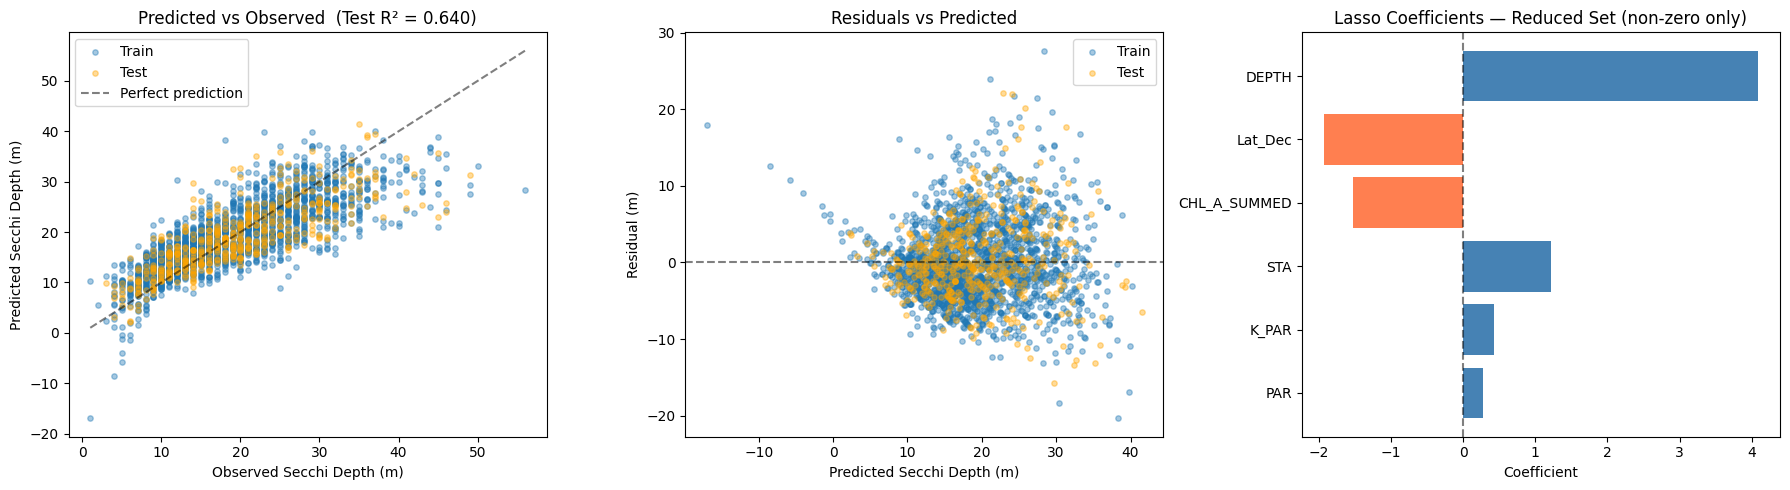

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs Observed
axes[0].scatter(y_train_r2, y_pred_train_r2, alpha=0.4, label='Train', s=15)
axes[0].scatter(y_test_r2,  y_pred_test_r2,  alpha=0.4, label='Test', color='orange', s=15)
lims_r2 = [min(y_train_r2.min(), y_test_r2.min()), max(y_train_r2.max(), y_test_r2.max())]
axes[0].plot(lims_r2, lims_r2, 'k--', alpha=0.5, label='Perfect prediction')
axes[0].set_xlabel('Observed Secchi Depth (m)')
axes[0].set_ylabel('Predicted Secchi Depth (m)')
axes[0].set_title(f'Predicted vs Observed  (Test R² = {r2_score(y_test_r2, y_pred_test_r2):.3f})')
axes[0].legend()

# 2. Residuals vs Predicted
res_train_r2 = y_train_r2 - y_pred_train_r2
res_test_r2  = y_test_r2  - y_pred_test_r2
axes[1].scatter(y_pred_train_r2, res_train_r2, alpha=0.4, label='Train', s=15)
axes[1].scatter(y_pred_test_r2,  res_test_r2,  alpha=0.4, label='Test', color='orange', s=15)
axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Predicted Secchi Depth (m)')
axes[1].set_ylabel('Residual (m)')
axes[1].set_title('Residuals vs Predicted')
axes[1].legend()

# 3. Feature coefficient bar plot (non-zero only)
coef_nz_r2 = coef_df_r2[coef_df_r2['Coefficient'] != 0]
colors_r2 = ['steelblue' if c > 0 else 'coral' for c in coef_nz_r2['Coefficient']]
axes[2].barh(range(len(coef_nz_r2)), coef_nz_r2['Coefficient'].values, color=colors_r2)
axes[2].set_yticks(range(len(coef_nz_r2)))
axes[2].set_yticklabels(coef_nz_r2['Feature'].values)
axes[2].invert_yaxis()
axes[2].axvline(0, color='k', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Coefficient')
axes[2].set_title('Lasso Coefficients — Reduced Set (non-zero only)')

plt.tight_layout()
plt.show()

#### Lasso Regression — Reduced Feature Set with Log-Transformed Response
Log-transform `Secchi` to stabilise variance (combat heteroscedasticity). Model is fit on `log(Secchi)`; predictions are back-transformed with `exp()` for RMSE and diagnostic plots.

In [70]:
cast_complete_log = cast_df[features_r2 + [target]].dropna(subset=[target]).copy()

X_log = cast_complete_log[features_r2].values
y_log = np.log(cast_complete_log[target].values)   # log-transform response

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

imputer_log = SimpleImputer(strategy='median')
X_train_log_imp = imputer_log.fit_transform(X_train_log)
X_test_log_imp  = imputer_log.transform(X_test_log)

scaler_log = StandardScaler()
X_train_log_sc = scaler_log.fit_transform(X_train_log_imp)
X_test_log_sc  = scaler_log.transform(X_test_log_imp)

lasso_log = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=10000, random_state=42)
lasso_log.fit(X_train_log_sc, y_train_log)

# Predictions on log scale
y_pred_train_log = lasso_log.predict(X_train_log_sc)
y_pred_test_log  = lasso_log.predict(X_test_log_sc)

# Back-transform for interpretable metrics
y_pred_train_bt = np.exp(y_pred_train_log)
y_pred_test_bt  = np.exp(y_pred_test_log)
y_train_bt      = np.exp(y_train_log)
y_test_bt       = np.exp(y_test_log)

print("=" * 50)
print("LASSO RESULTS — LOG-TRANSFORMED RESPONSE")
print("=" * 50)
print(f"Best alpha:  {lasso_log.alpha_:.6f}")
print(f"\n--- On log scale ---")
print(f"Train R²:    {r2_score(y_train_log, y_pred_train_log):.4f}")
print(f"Test  R²:    {r2_score(y_test_log,  y_pred_test_log):.4f}")
print(f"\n--- Back-transformed (original scale) ---")
print(f"Train RMSE:  {np.sqrt(mean_squared_error(y_train_bt, y_pred_train_bt)):.4f}")
print(f"Test  RMSE:  {np.sqrt(mean_squared_error(y_test_bt,  y_pred_test_bt)):.4f}")
print(f"Test  R²:    {r2_score(y_test_bt, y_pred_test_bt):.4f}")

cv_scores_log = cross_val_score(lasso_log, X_train_log_sc, y_train_log, cv=5, scoring='r2')
print(f"\n5-Fold CV R² (log scale): {cv_scores_log}")
print(f"CV R² mean ± std: {cv_scores_log.mean():.4f} ± {cv_scores_log.std():.4f}")

coef_df_log = pd.DataFrame({'Feature': features_r2, 'Coefficient': lasso_log.coef_})
coef_df_log['Abs_Coef'] = coef_df_log['Coefficient'].abs()
coef_df_log = coef_df_log.sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print(f"\n{'='*50}")
print("FEATURE COEFFICIENTS (sorted by |coef|)")
print(f"{'='*50}")
print(coef_df_log[['Feature', 'Coefficient']].to_string(index=False))
n_nonzero_log = (coef_df_log['Coefficient'] != 0).sum()
print(f"\nNon-zero coefficients: {n_nonzero_log} / {len(features_r2)}")

LASSO RESULTS — LOG-TRANSFORMED RESPONSE
Best alpha:  0.000453

--- On log scale ---
Train R²:    0.6702
Test  R²:    0.6887

--- Back-transformed (original scale) ---
Train RMSE:  5.3980
Test  RMSE:  5.6134
Test  R²:    0.5801

5-Fold CV R² (log scale): [0.67965964 0.68711815 0.65401359 0.61418464 0.68999272]
CV R² mean ± std: 0.6650 ± 0.0284

FEATURE COEFFICIENTS (sorted by |coef|)
     Feature  Coefficient
       DEPTH     0.217462
CHL_A_SUMMED    -0.173442
     Lat_Dec    -0.092886
         STA     0.052407
       K_PAR     0.014509
         PAR     0.002619

Non-zero coefficients: 6 / 6


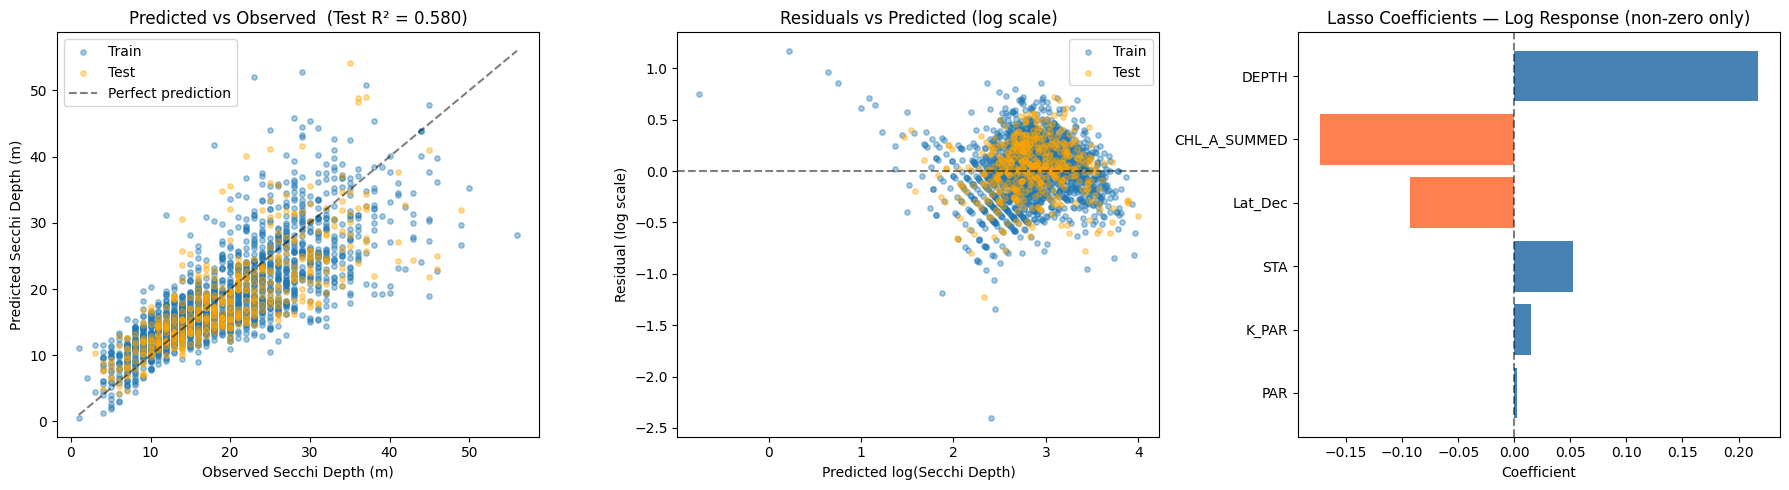

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs Observed (back-transformed)
axes[0].scatter(y_train_bt, y_pred_train_bt, alpha=0.4, label='Train', s=15)
axes[0].scatter(y_test_bt,  y_pred_test_bt,  alpha=0.4, label='Test', color='orange', s=15)
lims_log = [min(y_train_bt.min(), y_test_bt.min()), max(y_train_bt.max(), y_test_bt.max())]
axes[0].plot(lims_log, lims_log, 'k--', alpha=0.5, label='Perfect prediction')
axes[0].set_xlabel('Observed Secchi Depth (m)')
axes[0].set_ylabel('Predicted Secchi Depth (m)')
axes[0].set_title(f'Predicted vs Observed  (Test R² = {r2_score(y_test_bt, y_pred_test_bt):.3f})')
axes[0].legend()

# 2. Residuals vs Predicted (on log scale to assess homoscedasticity)
res_train_log = y_train_log - y_pred_train_log
res_test_log  = y_test_log  - y_pred_test_log
axes[1].scatter(y_pred_train_log, res_train_log, alpha=0.4, label='Train', s=15)
axes[1].scatter(y_pred_test_log,  res_test_log,  alpha=0.4, label='Test', color='orange', s=15)
axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Predicted log(Secchi Depth)')
axes[1].set_ylabel('Residual (log scale)')
axes[1].set_title('Residuals vs Predicted (log scale)')
axes[1].legend()

# 3. Feature coefficient bar plot (non-zero only)
coef_nz_log = coef_df_log[coef_df_log['Coefficient'] != 0]
colors_log = ['steelblue' if c > 0 else 'coral' for c in coef_nz_log['Coefficient']]
axes[2].barh(range(len(coef_nz_log)), coef_nz_log['Coefficient'].values, color=colors_log)
axes[2].set_yticks(range(len(coef_nz_log)))
axes[2].set_yticklabels(coef_nz_log['Feature'].values)
axes[2].invert_yaxis()
axes[2].axvline(0, color='k', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Coefficient')
axes[2].set_title('Lasso Coefficients — Log Response (non-zero only)')

plt.tight_layout()
plt.show()

Log transforming the response didn't help, residuals vs predicted looks worse and the R^2 on the original scale worsened (while log scale did better, this is unimportant)